In [46]:
import pandas as pd

In [47]:
metadata = pd.read_csv(
    "data/LJSpeech-1.1/metadata.csv", sep="|", names=["sample", "text", "text_norm"]
)

In [48]:
metadata

,sample,text,text_norm
0,LJ001-0001,"Printing, in the only sense with which we are ...","Printing, in the only sense with which we are ..."
1,LJ001-0002,in being comparatively modern.,in being comparatively modern.
2,LJ001-0003,For although the Chinese took impressions from...,For although the Chinese took impressions from...
3,LJ001-0004,"produced the block books, which were the immed...","produced the block books, which were the immed..."
4,LJ001-0005,the invention of movable metal letters in the ...,the invention of movable metal letters in the ...
...,...,...,...
13095,LJ050-0274,made certain recommendations which it believes...,made certain recommendations which it believes...
13096,LJ050-0275,materially improve upon the procedures in effe...,materially improve upon the procedures in effe...
13097,LJ050-0276,"As has been pointed out, the Commission has no...","As has been pointed out, the Commission has no..."
13098,LJ050-0277,with the active cooperation of the responsible...,with the active cooperation of the responsible...


In [49]:
chars = set()
for text in metadata["text_norm"]:
    chars |= set(str(text))

In [50]:
"".join(sorted(list(chars)))

' !"\'(),-.:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ[]abcdefghijklmnopqrstuvwxyzàâèéêü’“”'

<Axes: >

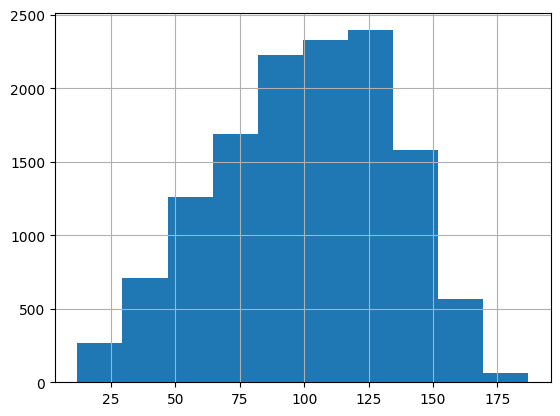

In [51]:
metadata["text_norm"].str.len().hist()

In [52]:
data_root = "data/LJSpeech-1.1/wavs/"
metadata["filepath"] = data_root + metadata["sample"] + ".wav"

In [53]:
metadata["is_val"] = metadata["sample"].apply(lambda x: hash(x) % 10) == 0

In [64]:
train = metadata[~metadata["is_val"]].drop("is_val", axis=1).reset_index(drop=True)
val = metadata[metadata["is_val"]].drop("is_val", axis=1).reset_index(drop=True)

In [67]:
train.to_csv("data/train.csv", index=False)
val.to_csv("data/val.csv", index=False)